# Statistics for Machine Learning

## Why Statistics?

Statistics is how we extract reliable knowledge from noisy data. In ML: How confident are we in a model's performance? Is the improvement from a new model real or just noise? How do we estimate model parameters from data? All of these require statistical thinking.

---

## Table of Contents
1. Descriptive Statistics
2. Sampling Theory
3. Point Estimation: MLE and MAP
4. Confidence Intervals
5. Hypothesis Testing
6. Statistical Tests (t-test, chi-square, ANOVA, Mann-Whitney)
7. Effect Size
8. Multiple Testing Correction
9. Bootstrap Methods
10. Bayesian Inference

## 1. Descriptive Statistics

### Measures of Central Tendency

**Mean:**
$$\bar{x} = \frac{1}{n}\sum_{i=1}^n x_i$$

**Median:** Middle value when sorted. Robust to outliers.

**Mode:** Most frequent value.

### Measures of Spread

**Variance (sample):**
$$s^2 = \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})^2$$

The $n-1$ (Bessel's correction) makes $s^2$ an unbiased estimator of $\sigma^2$.

**Standard Deviation:** $s = \sqrt{s^2}$

**IQR (Interquartile Range):** $IQR = Q_3 - Q_1$ robust spread measure.

**Mean Absolute Deviation (MAD):**
$$MAD = \frac{1}{n}\sum_{i=1}^n |x_i - \bar{x}|$$

### Shape

**Skewness:**
$$\text{skew} = \frac{\frac{1}{n}\sum(x_i-\bar{x})^3}{s^3}$$
Positive skew: right tail. Negative skew: left tail.

**Kurtosis:**
$$\text{kurt} = \frac{\frac{1}{n}\sum(x_i-\bar{x})^4}{s^4} - 3$$
Excess kurtosis: 0 for Normal. Positive = heavy tails (leptokurtic). Negative = light tails (platykurtic).

=== Descriptive Statistics ===
Mean:       65.30
Median:     51.50
Std Dev:    48.77
Variance:   2378.90
Q1:         44.26
Q3:         59.54
IQR:        15.28
Skewness:   2.9186
Kurtosis:   7.7664


/tmp/ipykernel_113666/1725069502.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(data, vert=True)


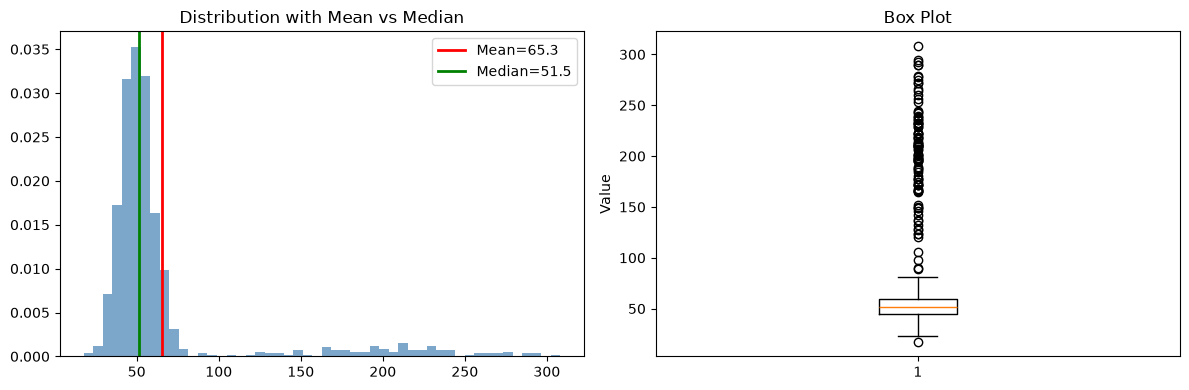

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
# Skewed data (income-like)
data = np.concatenate([
    np.random.normal(50, 10, 900),
    np.random.normal(200, 50, 100)  # outliers
])

print("=== Descriptive Statistics ===")
print(f"Mean:       {np.mean(data):.2f}")
print(f"Median:     {np.median(data):.2f}")
print(f"Std Dev:    {np.std(data, ddof=1):.2f}")
print(f"Variance:   {np.var(data, ddof=1):.2f}")
print(f"Q1:         {np.percentile(data, 25):.2f}")
print(f"Q3:         {np.percentile(data, 75):.2f}")
print(f"IQR:        {np.percentile(data, 75) - np.percentile(data, 25):.2f}")
print(f"Skewness:   {stats.skew(data):.4f}")
print(f"Kurtosis:   {stats.kurtosis(data):.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(data, bins=50, density=True, alpha=0.7, color='steelblue')
axes[0].axvline(np.mean(data), color='red', linewidth=2, label=f'Mean={np.mean(data):.1f}')
axes[0].axvline(np.median(data), color='green', linewidth=2, label=f'Median={np.median(data):.1f}')
axes[0].set_title('Distribution with Mean vs Median')
axes[0].legend()

axes[1].boxplot(data, vert=True)
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

## 3. Point Estimation: MLE and MAP

### Maximum Likelihood Estimation (MLE)

**Goal:** Find parameters $\theta$ that maximize the probability of observing the data $X = \{x_1, \ldots, x_n\}$.

$$\hat{\theta}_{MLE} = \arg\max_\theta P(X \mid \theta) = \arg\max_\theta \prod_{i=1}^n p(x_i \mid \theta)$$

Taking the log (log-likelihood):
$$\hat{\theta}_{MLE} = \arg\max_\theta \ell(\theta) = \arg\max_\theta \sum_{i=1}^n \log p(x_i \mid \theta)$$

**Example Gaussian MLE:**
Given $x_i \sim \mathcal{N}(\mu, \sigma^2)$:
$$\ell(\mu, \sigma^2) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i - \mu)^2$$

Setting $\frac{\partial\ell}{\partial\mu} = 0$ gives: $\hat{\mu}_{MLE} = \bar{x}$

Setting $\frac{\partial\ell}{\partial\sigma^2} = 0$ gives: $\hat{\sigma}^2_{MLE} = \frac{1}{n}\sum(x_i - \bar{x})^2$ (biased!)

**MLE = minimizing cross-entropy loss in classification** (log loss = negative log-likelihood).

### Maximum A Posteriori (MAP)

Add a prior $P(\theta)$, maximize the posterior:
$$\hat{\theta}_{MAP} = \arg\max_\theta P(\theta \mid X) = \arg\max_\theta \left[\log P(X \mid \theta) + \log P(\theta)\right]$$

**Connection to regularization:**
- Gaussian prior on $\theta$: $\log P(\theta) = -\frac{\|\theta\|_2^2}{2\sigma^2}$ → **L2 regularization (Ridge)**
- Laplace prior on $\theta$: $\log P(\theta) = -\frac{\|\theta\|_1}{b}$ → **L1 regularization (Lasso)**

In [2]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm

# MLE for Gaussian
np.random.seed(42)
true_mu, true_sigma = 5.0, 2.0
data = np.random.normal(true_mu, true_sigma, 200)

# Analytical MLE
mu_mle = np.mean(data)
sigma2_mle = np.mean((data - mu_mle)**2)  # biased (divides by n)
sigma2_unbiased = np.var(data, ddof=1)    # unbiased (divides by n-1)

print(f"True: μ={true_mu}, σ²={true_sigma**2}")
print(f"MLE:  μ={mu_mle:.4f}, σ²={sigma2_mle:.4f} (biased)")
print(f"Unbiased σ²={sigma2_unbiased:.4f}")

# MLE via numerical optimization
def neg_log_likelihood(params, data):
    mu, log_sigma = params
    sigma = np.exp(log_sigma)  # ensure positive
    return -np.sum(norm.logpdf(data, mu, sigma))

result = minimize(neg_log_likelihood, [0, 0], args=(data,), method='BFGS')
print(f"\nNumerical MLE: μ={result.x[0]:.4f}, σ={np.exp(result.x[1]):.4f}")

# MLE for logistic regression (binary classification)
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X, y = load_breast_cancer(return_X_y=True)
X_scaled = StandardScaler().fit_transform(X)

# Without regularization = pure MLE
lr_mle = LogisticRegression(C=1e10, max_iter=1000)
lr_mle.fit(X_scaled, y)

# With L2 = MAP with Gaussian prior
lr_map = LogisticRegression(C=1.0, max_iter=1000)
lr_map.fit(X_scaled, y)

print(f"\nLogistic Regression:")
print(f"MLE (no reg): ||w|| = {np.linalg.norm(lr_mle.coef_):.4f}")
print(f"MAP (L2 reg): ||w|| = {np.linalg.norm(lr_map.coef_):.4f} (smaller = regularized)")

True: μ=5.0, σ²=4.0
MLE:  μ=4.9185, σ²=3.4497 (biased)
Unbiased σ²=3.4671

Numerical MLE: μ=4.9185, σ=1.8573



Logistic Regression:
MLE (no reg): ||w|| = 46701.4042
MAP (L2 reg): ||w|| = 3.8430 (smaller = regularized)


## 4. Confidence Intervals

A **$(1-\alpha)\times 100\%$ confidence interval** for parameter $\theta$ is an interval $(L, U)$ such that:
$$P(L \leq \theta \leq U) = 1 - \alpha$$

### CI for Population Mean (known $\sigma$)
$$\bar{x} \pm z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}}$$
where $z_{\alpha/2}$ is the critical value: $z_{0.025} = 1.96$ for 95% CI.

### CI for Population Mean (unknown $\sigma$)
$$\bar{x} \pm t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}}$$
Uses t-distribution with $n-1$ degrees of freedom.

**Interpretation:** If we repeated the experiment many times, 95% of the computed confidence intervals would contain the true parameter. (It does NOT mean "there's a 95% probability the parameter is in this specific interval.")

## 5. Hypothesis Testing

### Framework
1. **Null hypothesis** $H_0$: Default assumption (e.g., "no difference", "no effect")
2. **Alternative hypothesis** $H_1$: What we want to prove
3. **Significance level** $\alpha$: Threshold for rejecting $H_0$ (typically 0.05)
4. **Test statistic**: A function of the data
5. **p-value**: $P(\text{test statistic as extreme as observed} \mid H_0 \text{ true})$

### Decision Rule
- **Reject $H_0$** if p-value $< \alpha$
- **Fail to reject $H_0$** if p-value $\geq \alpha$

### Error Types
| | $H_0$ True | $H_0$ False |
|--|--|--|
| **Reject $H_0$** | Type I Error (False Positive), rate = $\alpha$ | Correct (Power = $1-\beta$) |
| **Fail to reject** | Correct | Type II Error (False Negative), rate = $\beta$ |

**Power** = $1 - \beta$ = probability of correctly detecting a true effect.

**In ML:** Used for A/B testing models, comparing algorithm performance, feature selection.

## 6. Statistical Tests

### One-Sample t-test
Test if population mean equals a hypothesized value $\mu_0$:
$$t = \frac{\bar{x} - \mu_0}{s/\sqrt{n}} \sim t_{n-1} \text{ under } H_0$$

### Two-Sample t-test (Welch's)
Test if two population means are equal:
$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

### Chi-square Test of Independence
$$\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}, \quad E_{ij} = \frac{R_i C_j}{N}$$
where $O_{ij}$ = observed, $E_{ij}$ = expected frequencies.

### One-way ANOVA
Test if $k$ group means are equal:
$$F = \frac{\text{Between-group variance}}{\text{Within-group variance}} = \frac{SS_B/(k-1)}{SS_W/(N-k)} \sim F_{k-1, N-k}$$

### Mann-Whitney U Test
Non-parametric alternative to t-test (no normality assumption):
$$U_1 = n_1 n_2 + \frac{n_1(n_1+1)}{2} - R_1$$
where $R_1$ is the sum of ranks in group 1.

In [3]:
import numpy as np
from scipy import stats

np.random.seed(42)

# 1. One-sample t-test: Is model accuracy > 90%?
accuracies = np.array([0.91, 0.89, 0.92, 0.88, 0.93, 0.91, 0.90, 0.87, 0.94, 0.92])
t_stat, p_val = stats.ttest_1samp(accuracies, 0.90)
print("=== One-Sample t-test: Is mean accuracy > 90%? ===")
print(f"Sample mean: {accuracies.mean():.4f}")
print(f"t-statistic: {t_stat:.4f}, p-value (two-tailed): {p_val:.4f}")
print(f"Reject H0 (α=0.05): {p_val < 0.05}")

# 2. Two-sample t-test: Model A vs Model B
model_A = np.random.normal(0.85, 0.05, 30)
model_B = np.random.normal(0.88, 0.05, 30)
t_stat2, p_val2 = stats.ttest_ind(model_A, model_B)
print("\n=== Two-Sample t-test: Model A vs Model B ===")
print(f"A mean: {model_A.mean():.4f}, B mean: {model_B.mean():.4f}")
print(f"t-statistic: {t_stat2:.4f}, p-value: {p_val2:.4f}")
print(f"Significant difference (α=0.05): {p_val2 < 0.05}")

# 3. Chi-square test: Feature independence
observed = np.array([[50, 30], [20, 100]])
chi2, p_chi, dof, expected = stats.chi2_contingency(observed)
print("\n=== Chi-Square Test of Independence ===")
print(f"Chi2={chi2:.4f}, p-value={p_chi:.4f}, dof={dof}")
print(f"Independent (α=0.05): {p_chi > 0.05}")

# 4. One-way ANOVA: 3 algorithms
algo1 = np.random.normal(0.80, 0.03, 20)
algo2 = np.random.normal(0.82, 0.03, 20)
algo3 = np.random.normal(0.85, 0.03, 20)
f_stat, p_anova = stats.f_oneway(algo1, algo2, algo3)
print("\n=== One-way ANOVA: 3 Algorithms ===")
print(f"F-statistic: {f_stat:.4f}, p-value: {p_anova:.4f}")
print(f"Significant difference: {p_anova < 0.05}")

# 5. Mann-Whitney U test (non-parametric)
mw_stat, p_mw = stats.mannwhitneyu(model_A, model_B, alternative='two-sided')
print("\n=== Mann-Whitney U Test (non-parametric) ===")
print(f"U-statistic: {mw_stat:.4f}, p-value: {p_mw:.4f}")

=== One-Sample t-test: Is mean accuracy > 90%? ===
Sample mean: 0.9070
t-statistic: 1.0000, p-value (two-tailed): 0.3434
Reject H0 (α=0.05): False

=== Two-Sample t-test: Model A vs Model B ===
A mean: 0.8406, B mean: 0.8739
t-statistic: -2.8211, p-value: 0.0065
Significant difference (α=0.05): True

=== Chi-Square Test of Independence ===
Chi2=42.3306, p-value=0.0000, dof=1
Independent (α=0.05): False

=== One-way ANOVA: 3 Algorithms ===
F-statistic: 16.7797, p-value: 0.0000
Significant difference: True

=== Mann-Whitney U Test (non-parametric) ===
U-statistic: 269.0000, p-value: 0.0076


## 7. Effect Size

**p-value tells you IF an effect is real. Effect size tells you HOW BIG it is.**

### Cohen's d (two groups)
$$d = \frac{\bar{x}_1 - \bar{x}_2}{s_{\text{pooled}}}, \quad s_{\text{pooled}} = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}}$$

Interpretation: $|d| < 0.2$ small, $|d| < 0.5$ medium, $|d| < 0.8$ large.

### Eta-squared (ANOVA)
$$\eta^2 = \frac{SS_B}{SS_T}$$

### Correlation coefficient $r$
$$r^2 = \text{proportion of variance explained}$$

**In ML:** A model improvement from 90.0% to 90.1% accuracy may be statistically significant with 1M samples but practically meaningless. Always report effect sizes alongside p-values.

## 8. Multiple Testing Correction

### Problem
If we run 100 tests at $\alpha=0.05$, we expect ~5 false positives by chance!

**Family-wise error rate (FWER):** $P(\geq 1 \text{ false positive}) = 1 - (1-\alpha)^m$

### Bonferroni Correction (Conservative)
$$\alpha_{\text{adjusted}} = \frac{\alpha}{m}$$

Controls FWER but very conservative misses real effects.

### Benjamini-Hochberg (FDR Recommended)
Controls the **False Discovery Rate** (expected proportion of false positives among all discoveries).

Procedure: Sort p-values $p_{(1)} \leq \cdots \leq p_{(m)}$. Reject all $H_{(i)}$ where $i \leq \max\{i : p_{(i)} \leq \frac{i}{m}\alpha\}$.

**In ML:** Feature selection with many features, comparing many model variants, genome-wide association studies (GWAS).

## 9. Bootstrap Methods

**Idea:** Estimate the sampling distribution of any statistic by resampling with replacement from the data.

$$\hat{\theta}^* = T(X_1^*, \ldots, X_n^*), \quad X_i^* \sim \hat{F}_n$$

**Bootstrap CI (percentile method):**
$$CI_{1-\alpha} = [\hat{\theta}^*_{(\alpha/2)}, \hat{\theta}^*_{(1-\alpha/2)}]$$

**Advantages:** No distributional assumptions. Works for any statistic (median, correlation, AUC, etc.).

Original mean accuracy: 0.8440
Bootstrap 95% CI: [0.8310, 0.8570]


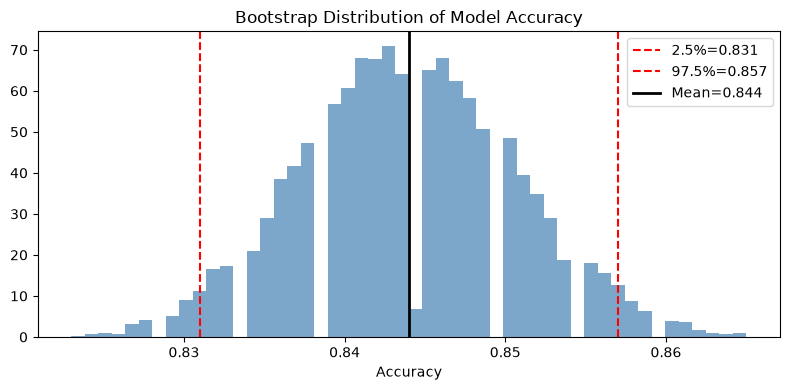

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Bootstrap CI for model accuracy
n_bootstrap = 5000
model_scores = np.array([0.82, 0.85, 0.83, 0.87, 0.84, 0.86, 0.81, 0.88, 0.85, 0.83])

bootstrap_means = []
for _ in range(n_bootstrap):
    resample = np.random.choice(model_scores, size=len(model_scores), replace=True)
    bootstrap_means.append(np.mean(resample))

bootstrap_means = np.array(bootstrap_means)
ci_lower = np.percentile(bootstrap_means, 2.5)
ci_upper = np.percentile(bootstrap_means, 97.5)

print(f"Original mean accuracy: {model_scores.mean():.4f}")
print(f"Bootstrap 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(bootstrap_means, bins=50, density=True, alpha=0.7, color='steelblue')
ax.axvline(ci_lower, color='red', linestyle='--', label=f'2.5%={ci_lower:.3f}')
ax.axvline(ci_upper, color='red', linestyle='--', label=f'97.5%={ci_upper:.3f}')
ax.axvline(model_scores.mean(), color='black', linewidth=2, label=f'Mean={model_scores.mean():.3f}')
ax.set_title('Bootstrap Distribution of Model Accuracy')
ax.legend()
ax.set_xlabel('Accuracy')
plt.tight_layout()
plt.show()

## 10. Bayesian Inference

In Bayesian statistics, **parameters are random variables with probability distributions**.

$$\underbrace{p(\theta \mid X)}_{\text{posterior}} \propto \underbrace{p(X \mid \theta)}_{\text{likelihood}} \cdot \underbrace{p(\theta)}_{\text{prior}}$$

### Conjugate Priors
A prior is **conjugate** to a likelihood if the posterior has the same family as the prior.

| Likelihood | Conjugate Prior | Posterior |
|-----------|----------------|----------|
| Bernoulli/Binomial | Beta($\alpha$,$\beta$) | Beta($\alpha+k$, $\beta+n-k$) |
| Poisson | Gamma($\alpha$,$\beta$) | Gamma($\alpha+\sum k_i$, $\beta+n$) |
| Gaussian (known $\sigma$) | Gaussian($\mu_0$,$\sigma_0^2$) | Gaussian(updated) |

### Posterior Update (Beta-Binomial)
Prior: $p \sim \text{Beta}(\alpha, \beta)$. Observe $k$ successes in $n$ trials.
$$\text{Posterior: } p \sim \text{Beta}(\alpha + k, \beta + n - k)$$

**In ML:** Bayesian neural networks, Gaussian processes, Thompson sampling in bandits, Bayesian hyperparameter optimization.

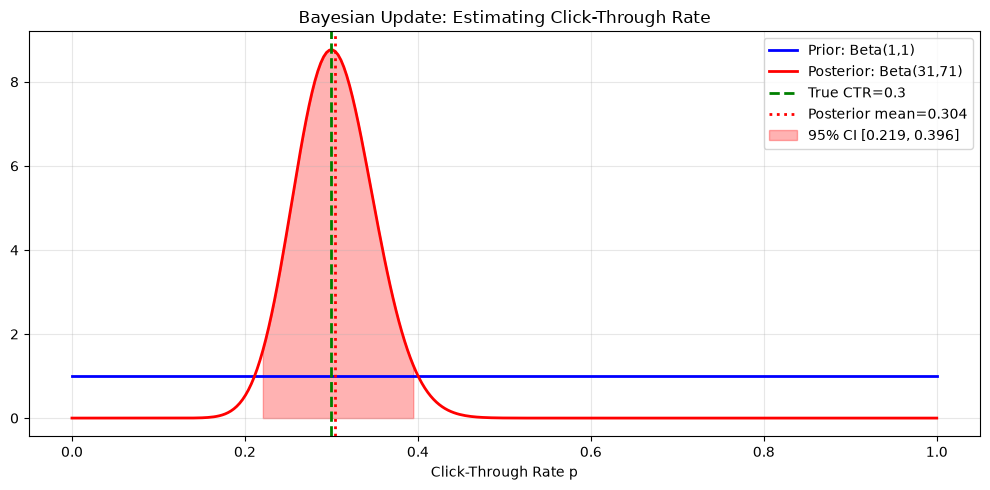

Posterior mean (MAP estimate): 0.3039
95% Credible Interval: [0.2190, 0.3961]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Bayesian update: estimating click-through rate
# Prior: Beta(1,1) = uniform (no prior knowledge)
prior_alpha, prior_beta = 1, 1

# Observe data: 30 clicks out of 100 impressions
clicks, impressions = 30, 100
post_alpha = prior_alpha + clicks
post_beta = prior_beta + (impressions - clicks)

x = np.linspace(0, 1, 300)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, beta.pdf(x, prior_alpha, prior_beta), 
        'b-', linewidth=2, label=f'Prior: Beta({prior_alpha},{prior_beta})')
ax.plot(x, beta.pdf(x, post_alpha, post_beta), 
        'r-', linewidth=2, label=f'Posterior: Beta({post_alpha},{post_beta})')
ax.axvline(0.3, color='green', linestyle='--', linewidth=2, label='True CTR=0.3')

posterior_mean = post_alpha / (post_alpha + post_beta)
ax.axvline(posterior_mean, color='red', linestyle=':', linewidth=2, 
           label=f'Posterior mean={posterior_mean:.3f}')

ci_lower = beta.ppf(0.025, post_alpha, post_beta)
ci_upper = beta.ppf(0.975, post_alpha, post_beta)
ax.fill_between(x, beta.pdf(x, post_alpha, post_beta),
                where=(x >= ci_lower) & (x <= ci_upper), alpha=0.3, color='red',
                label=f'95% CI [{ci_lower:.3f}, {ci_upper:.3f}]')

ax.set_title('Bayesian Update: Estimating Click-Through Rate')
ax.set_xlabel('Click-Through Rate p')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Posterior mean (MAP estimate): {posterior_mean:.4f}")
print(f"95% Credible Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")

## Additional Learning Resources

### Video Courses
- **StatQuest Statistics Fundamentals**: https://www.youtube.com/playlist?list=PLblh5JKOoLUK0FLuzwntyYI10UQFUhsY9
- **MIT 18.650 Statistics for Applications**: https://ocw.mit.edu/courses/18-650-statistics-for-applications-fall-2016/
- **Andrew Ng ML Diagnostics (bias/variance)**: https://www.coursera.org/learn/machine-learning

### Books
- **Think Stats (Free book)**: https://greenteapress.com/thinkstats2/
- **Statistical Rethinking (Bayesian)**: https://xcelab.net/rm/statistical-rethinking/
- **All of Statistics Wasserman**: https://link.springer.com/book/10.1007/978-0-387-21736-9
- **The Elements of Statistical Learning (Free)**: https://hastie.su.domains/ElemStatLearn/
- **Computer Age Statistical Inference (Free)**: https://hastie.su.domains/CASI/

### Papers
- **A/B Testing at Scale (Kohavi et al.)**: https://www.kdd.org/kdd2014/papers/kdd2014-kohavi.pdf
- **Beyond Bar and Line Graphs (Weissgerber)**: https://journals.plos.org/plosbiology/article?id=10.1371/journal.pbio.1002128

### Tools
- **scipy.stats documentation**: https://docs.scipy.org/doc/scipy/reference/stats.html
- **pingouin (statistical tests)**: https://pingouin-stats.org/
- **statsmodels**: https://www.statsmodels.org/